# Week 9 Phase 1.9 — Physics-specificity control

This notebook reads the frozen-path control artifacts. It does not run the 6,500-fit engine.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT=Path.cwd().resolve().parents[1]
OUT=ROOT/'outputs'/'week9_phase1_9_physics_specificity_control'

## 1. Why this control matters

Phase 1.8 showed that the Phase 1.7 gain is model-dominant. Here we ask whether the gain is specific to h, or whether any flexible parametric trend provides the same stabilization.

In [2]:
gate=pd.read_json(OUT/'baseline_gate.json', typ='series'); gate

Y00_q20_AULC_16_80                                                            0.81352
Y10_q20_AULC_16_80                                                           0.829972
budgets_16_80_per_run                                                              65
duplicate_query_violations                                                          0
initial_design_exact_matches                                                      100
keyholes                                                                           73
new_query_paths_generated                                                           0
outer_runs                                                                        100
outside_training_pool_violations                                                    0
population                                                                        405
queries_per_path                                                                   80
source                              outputs/week9_phas

## 2. Physics trend versus generic trend

Physics uses one standardized log(h) direction. Generic uses four independent standardized variables: log P, log VX, log LS, and ST. Both use the identical constrained 4D residual GP.

In [3]:
pd.read_csv(OUT/'primary_AULC_summary.csv')

,estimand,label,mean,ci_low,ci_high,decision
0,Y00,canonical 4D GPC,0.813520,0.806962,0.820372,PHYSICS_SPECIFIC_SUPPORTED
1,G10,generic trend + residual GP,0.812050,0.806797,0.817247,PHYSICS_SPECIFIC_SUPPORTED
2,Y10,physics trend + residual GP,0.829972,0.826498,0.833405,PHYSICS_SPECIFIC_SUPPORTED
3,physics_minus_generic,physics minus generic,0.017923,0.013442,0.022725,PHYSICS_SPECIFIC_SUPPORTED
4,generic_minus_4D,generic minus 4D,-0.001471,-0.005712,0.002606,PHYSICS_SPECIFIC_SUPPORTED


## 3. Main q20 AULC result

All three curves are evaluated on the same A0 prefix, so their differences are prediction-model differences.

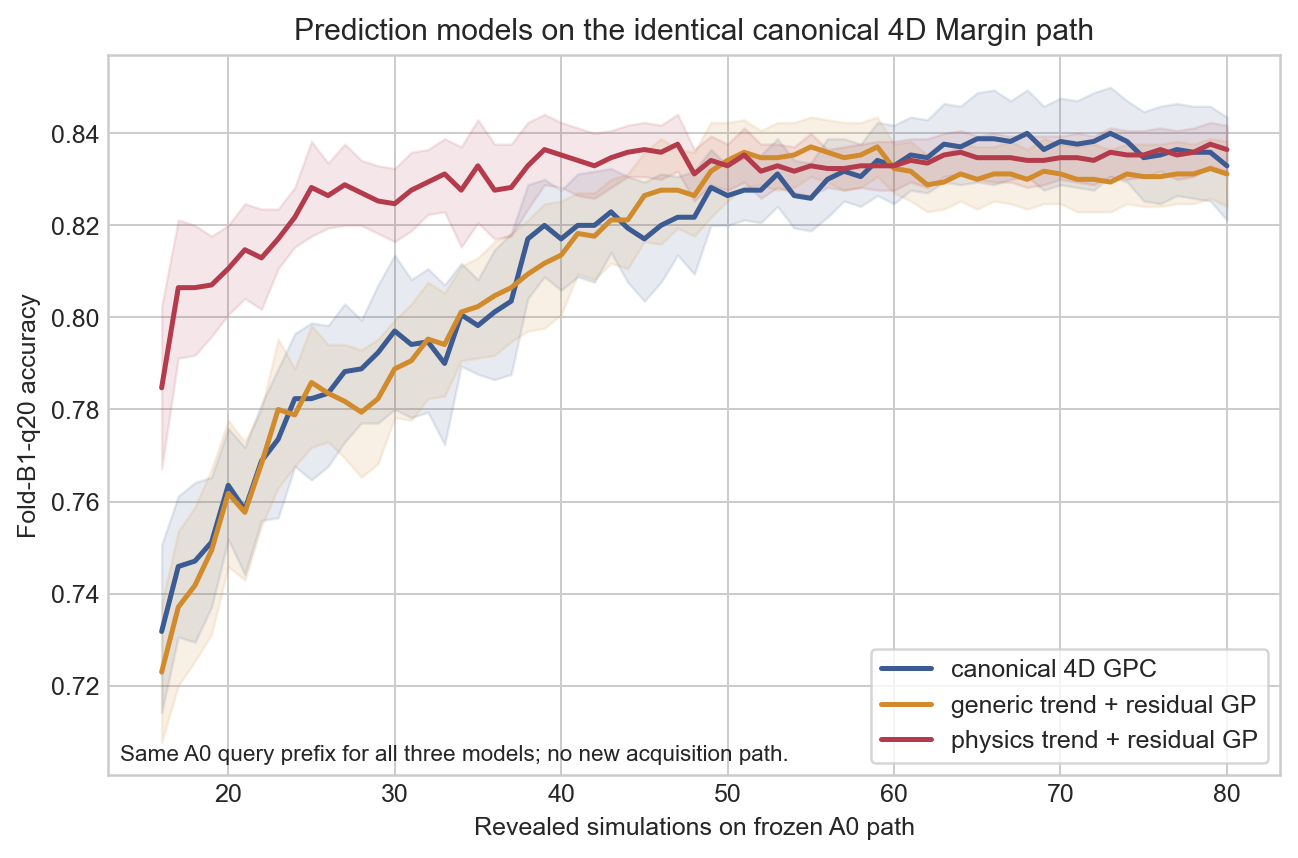

In [4]:
display(Image(filename=str(OUT/'figures'/'01_q20_learning_curves_same_A0.png')))

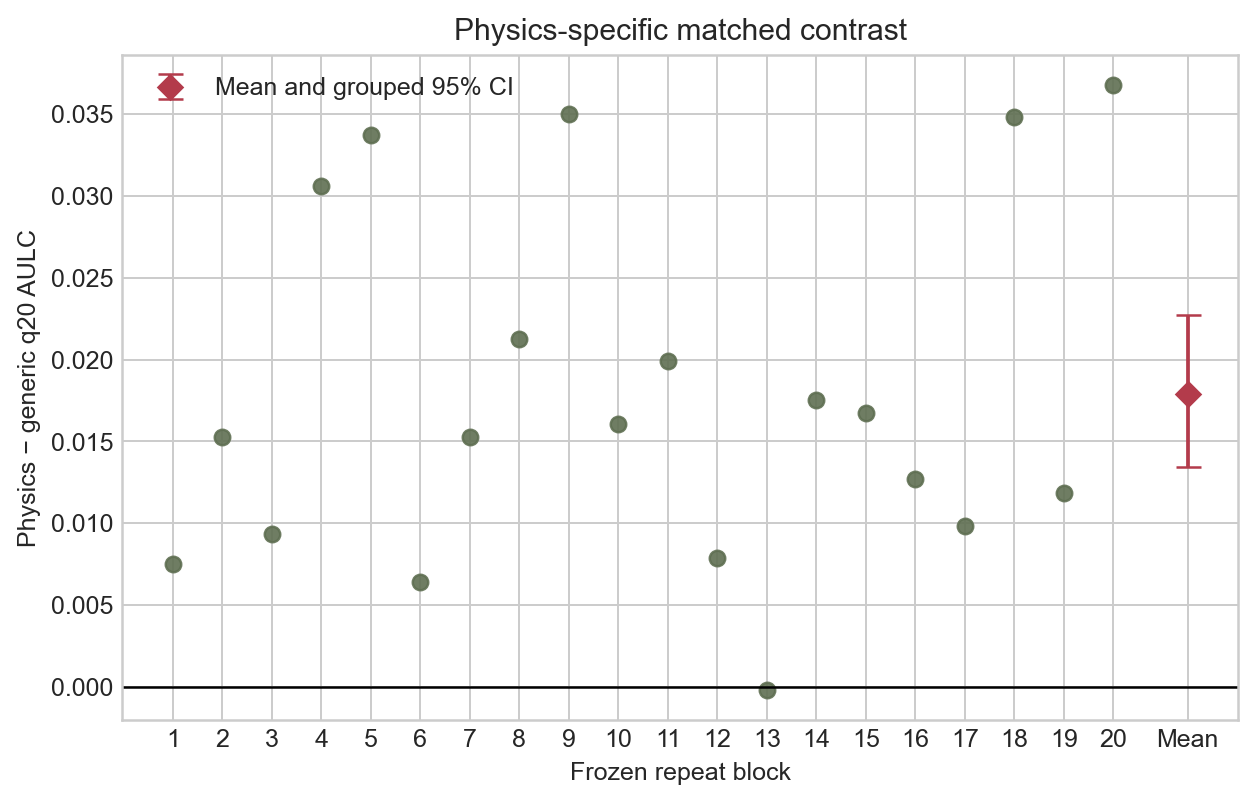

In [5]:
display(Image(filename=str(OUT/'figures'/'02_physics_minus_generic_repeat_contrast.png')))

## 4. Budget-16 low-data comparison

At budget 16, all methods have the same revealed simulations.

In [6]:
c=pd.read_csv(OUT/'budget_checkpoint_summary.csv'); c[(c.budget==16)&(c.subset.isin(['B1_q20','B1_q30','full81']))][['arm','subset','metric','mean','ci_low','ci_high']]

,arm,subset,metric,mean,ci_low,ci_high
0,G10,B1_q20,accuracy,0.722941,0.708235,0.737059
1,G10,B1_q20,balanced_accuracy,0.713047,0.692845,0.733023
2,G10,B1_q20,conduction_recall,0.756666,0.721172,0.792678
3,G10,B1_q20,false_negative,2.170000,1.800000,2.530000
4,G10,B1_q20,false_positive,2.540000,2.160000,2.910000
5,G10,B1_q20,keyhole_recall,0.669429,0.614506,0.725973
6,G10,B1_q30,balanced_accuracy,0.755001,0.733903,0.775873
7,G10,full81,balanced_accuracy,0.878561,0.863646,0.893715
48,Y00,B1_q20,accuracy,0.731765,0.714118,0.750588
49,Y00,B1_q20,balanced_accuracy,0.686194,0.660419,0.713693


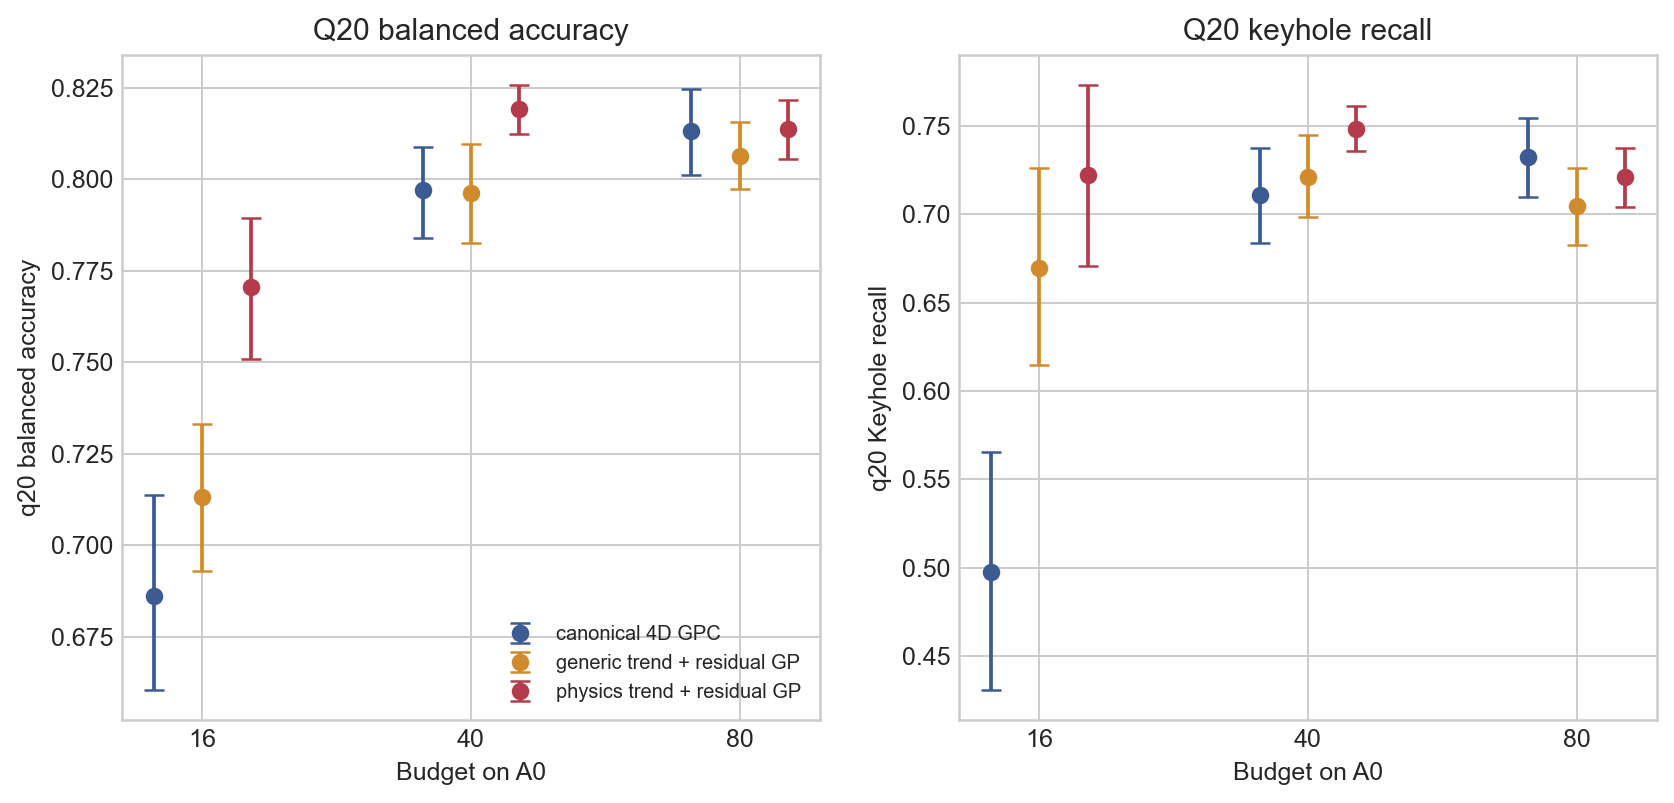

In [7]:
display(Image(filename=str(OUT/'figures'/'03_budget16_40_80_q20.png')))

## 5. Static sanity check and optimization diagnostic

Static held-out performance is secondary; bound hits are descriptive and are not used for tuning.

In [8]:
display(pd.read_csv(OUT/'static_model_summary.csv')); display(pd.read_csv(OUT/'hyperparameter_diagnostics.csv'))

,model,subset,repeat_blocks,mean_roc_auc,ci_low_roc_auc,ci_high_roc_auc,mean_pr_auc,ci_low_pr_auc,ci_high_pr_auc,mean_balanced_accuracy,ci_low_balanced_accuracy,ci_high_balanced_accuracy,mean_keyhole_recall,ci_low_keyhole_recall,ci_high_keyhole_recall
0,generic_trend_residual_gp,B1_q20,20,0.904232,0.900662,0.907602,0.804780,0.798772,0.810599,0.815128,0.807743,0.822461,0.714207,0.698315,0.730050
1,generic_trend_residual_gp,full81,20,0.990095,0.989813,0.990368,0.953569,0.951742,0.955123,0.924312,0.921422,0.927312,0.862329,0.856164,0.868493
2,gpc_4d,B1_q20,20,0.919710,0.916440,0.923139,0.867253,0.860762,0.873507,0.815909,0.803366,0.828286,0.732327,0.710092,0.754318
3,gpc_4d,full81,20,0.992587,0.992301,0.992897,0.968286,0.967283,0.969326,0.925087,0.919908,0.929915,0.866438,0.856832,0.876027
4,physics_ridge_residual_gp,B1_q20,20,0.910594,0.908982,0.912183,0.811526,0.807349,0.815702,0.819493,0.815420,0.823770,0.717183,0.707416,0.727737
5,physics_ridge_residual_gp,full81,20,0.990993,0.990753,0.991205,0.956724,0.954649,0.958352,0.925716,0.924421,0.927010,0.864384,0.861644,0.867123


,arm,label,scope,fits,residual_sd_lower_bound_fraction,residual_sd_upper_bound_fraction,length_scale_lower_bound_fraction,length_scale_upper_bound_fraction,convergence_warning_fraction,fallback_count,mean_residual_sd,mean_length_scale,mean_residual_rms_full81,mean_residual_rms_B1_q20
0,G10,generic trend + residual GP,all_16_80,6500,0.050154,0.916154,0.068462,0.155538,0.986615,0,0.939518,1.579988,0.131952,0.185709
1,G10,generic trend + residual GP,budget_16,100,0.130000,0.780000,0.280000,0.560000,1.000000,0,0.822305,2.467440,0.055061,0.056554
2,G10,generic trend + residual GP,budget_40,100,0.040000,0.940000,0.030000,0.090000,0.990000,0,0.960881,1.511151,0.128092,0.182086
3,G10,generic trend + residual GP,budget_80,100,0.000000,1.000000,0.000000,0.000000,1.000000,0,1.000000,1.230416,0.187264,0.280255
4,Y10,physics trend + residual GP,all_16_80,6500,0.359077,0.150769,0.154462,0.175692,0.573077,0,0.453829,1.332034,0.056674,0.090811
5,Y10,physics trend + residual GP,budget_16,100,0.560000,0.380000,0.210000,0.560000,1.000000,0,0.419367,2.735481,0.031357,0.038224
6,Y10,physics trend + residual GP,budget_40,100,0.470000,0.080000,0.190000,0.180000,0.640000,0,0.359795,1.239035,0.037547,0.062168
7,Y10,physics trend + residual GP,budget_80,100,0.050000,0.330000,0.060000,0.010000,0.410000,0,0.733268,0.930387,0.124156,0.206131


## 6. Safe conclusion

In [9]:
print((OUT/'SUPERVISOR_PHASE1_9_ONE_PAGE.md').read_text(encoding='utf-8'))

# Week 9 Phase 1.9 — supervisor one-page

## Frozen-path control

All three prediction models use the exact same canonical 4D Margin query path A0. No new query trajectory was generated. The only new arm replaces the one-dimensional fixed h trend by standardized `log P`, `log VX`, `log LS`, and `ST`; the residual Matérn-3/2 GP and its bounds remain unchanged.

## Primary Fold-B1-q20 AULC, budgets 16–80

- Generic G10: **0.812049632**.
- Physics Y10: **0.829972426**.
- Physics minus generic: **+0.017922794**, grouped 95% CI [+0.013441981, +0.022725299].
- Generic minus canonical 4D: **-0.001470588**, grouped 95% CI [-0.005712431, +0.002605813].
- Decision: **PHYSICS_SPECIFIC_SUPPORTED**.

At budget 16, q20 accuracy is 4D=0.731765, generic=0.722941, physics=0.784706. The generic trend does **not** reproduce most of the Phase 1.7 gain: its AULC contrast against 4D is statistically unresolved and slightly negative in mean.

## Optimization diagnostic

Residual-SD upper-bound fractions are 